# Clase 3 — Significado por contexto

**Módulo de Análisis de Datos de Texto · Notebook 3 de 5**

En las clases anteriores cada palabra era una **dimensión aislada** del vocabulario. Eso significa que `"perro"` y `"gato"` son tan distintos entre sí como `"perro"` y `"avión"` — una limitación grave para capturar significado.

Hoy haremos una **reducción de dimensionalidad** sobre la matriz TF-IDF con `TruncatedSVD`. Esto nos da dimensiones **latentes** que capturan estructura semántica: en este espacio reducido las palabras relacionadas quedan cerca.

> Es la misma idea que está detrás de los *embeddings* modernos (word2vec, GloVe), y el mismo principio que vieron como SVD en filtrado colaborativo: descubrir dimensiones ocultas que explican los datos.

## 1. Punto de partida: la matriz TF-IDF

In [1]:
# Corpus de noticias en español (40 documentos cortos, 4 temas).
# Está embebido aquí para que el notebook sea autocontenido.

CORPUS = [
    # --- tecnología ---
    "Una empresa de tecnología presentó un nuevo modelo de inteligencia artificial capaz de generar texto en varios idiomas.",
    "El nuevo procesador promete duplicar la velocidad de los computadores portátiles sin aumentar el consumo de energía.",
    "Los algoritmos de aprendizaje automático están transformando la forma en que las empresas analizan datos masivos.",
    "Un grupo de investigadores publicó un modelo de lenguaje entrenado con miles de millones de palabras en español.",
    "La compañía lanzó una actualización de software que mejora la seguridad y corrige varios errores críticos.",
    "Expertos en ciberseguridad advierten sobre el aumento de ataques con inteligencia artificial generativa.",
    "El nuevo teléfono incorpora una cámara con procesamiento neuronal y reconocimiento de escenas en tiempo real.",
    "Los chips fabricados con tecnología de tres nanómetros llegarán al mercado el próximo año.",
    "Una startup colombiana desarrolló una aplicación que usa modelos de lenguaje para asesoría legal automatizada.",
    "El centro de datos consume menos energía gracias a un sistema de refrigeración basado en agua reciclada.",
    # --- deportes ---
    "El equipo nacional ganó el partido por tres goles a uno en el estadio principal de la capital.",
    "La selección de fútbol clasificó al mundial tras vencer a su rival histórico en tiempo de descuento.",
    "El ciclista colombiano subió al podio en la última etapa de la competencia europea.",
    "Un nuevo récord mundial fue establecido en los cien metros planos durante el campeonato.",
    "El entrenador anunció cambios en la alineación titular para el próximo partido decisivo.",
    "La final del torneo de baloncesto se jugará el sábado entre los dos mejores equipos del país.",
    "El tenista venció en cinco sets a su rival y avanzó a la final del torneo de Grand Slam.",
    "La atleta rompió la marca regional en lanzamiento de jabalina durante los juegos panamericanos.",
    "El nadador colombiano se clasificó a los juegos olímpicos tras una temporada excepcional.",
    "El partido fue suspendido por lluvia y se reanudará mañana en el mismo estadio.",
    # --- política ---
    "El gobierno anunció una nueva reforma tributaria que afectará a las grandes empresas del país.",
    "El congreso aprobó la ley de presupuesto general tras tres jornadas de intenso debate.",
    "La oposición criticó las medidas económicas anunciadas por el ministerio de hacienda esta semana.",
    "El presidente recibió a los líderes regionales para discutir la situación de seguridad en el sur del país.",
    "Las elecciones regionales se celebrarán en octubre con más de cuarenta millones de votantes habilitados.",
    "La corte constitucional declaró inexequible un artículo clave de la última reforma laboral aprobada.",
    "El alcalde presentó el plan de desarrollo con énfasis en movilidad y educación pública.",
    "Un acuerdo de paz entre las facciones políticas permitirá retomar el diálogo sobre la reforma rural.",
    "La ministra de educación defendió ante el congreso el aumento del presupuesto para universidades públicas.",
    "Los partidos políticos comenzaron las negociaciones para definir candidatos a la próxima campaña presidencial.",
    # --- cultura ---
    "La nueva película del director colombiano fue seleccionada para competir en el festival de cine de Cannes.",
    "El museo nacional inauguró una exposición sobre arte precolombino con piezas inéditas del periodo muisca.",
    "Un libro de poesía colombiana ganó el premio internacional de literatura en lengua española este año.",
    "La banda anunció gira mundial con conciertos en quince ciudades de América Latina y Europa.",
    "El festival de cine independiente proyectará más de cien películas durante dos semanas en la capital.",
    "La orquesta sinfónica estrenó una obra del compositor antioqueño con gran acogida del público.",
    "El teatro municipal presenta esta semana una adaptación contemporánea de una obra clásica del siglo de oro.",
    "Una escritora joven publicó su primera novela y ya ha sido traducida a cinco idiomas.",
    "El documental sobre música tradicional del pacífico colombiano fue estrenado en una plataforma de streaming.",
    "La feria del libro recibió más de medio millón de visitantes y cerró con un balance positivo.",
]

LABELS = (
    ["tecnología"] * 10
    + ["deportes"] * 10
    + ["política"] * 10
    + ["cultura"] * 10
)

print(f'Corpus: {len(CORPUS)} documentos en {len(set(LABELS))} categorías.')

Corpus: 40 documentos en 4 categorías.


In [2]:
# Proceso de quitar stopwords y contrucción de matirz TF-IDF
import nltk; nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

SW = sorted(stopwords.words("spanish"))
tfv = TfidfVectorizer(stop_words=SW, lowercase=True, min_df=2)
X = tfv.fit_transform(CORPUS)           # 40 docs x V términos
terms = tfv.get_feature_names_out()
print(f"TF-IDF: {X.shape[0]} documentos x {X.shape[1]} términos (espacio disperso)")

TF-IDF: 40 documentos x 52 términos (espacio disperso)


## 2. Reducción de dimensionalidad con TruncatedSVD

`TruncatedSVD` factoriza una matriz dispersa en componentes latentes. Pasamos de cientos de dimensiones a, digamos, **50**: cada documento queda representado por 50 números que combinan información de muchos términos.

In [8]:
from sklearn.decomposition import TruncatedSVD

K = 25                                  # dimensiones latentes, cantidad de palabras
svd = TruncatedSVD(n_components=K, random_state=0)
X_red = svd.fit_transform(X)            # 40 docs x 50

print(f"Antes: {X.shape}")
print(f"Después: {X_red.shape}    (denso, todos los valores son útiles)")
print(f"Varianza explicada por los 50 componentes: {svd.explained_variance_ratio_.sum():.3f}")

Antes: (40, 52)
Después: (40, 25)    (denso, todos los valores son útiles)
Varianza explicada por los 50 componentes: 0.904


## 3. Visualizar los documentos en 2D

Si reducimos a solo **2 dimensiones**, podemos ver el corpus completo en un plano. Las dimensiones latentes capturan los temas dominantes.

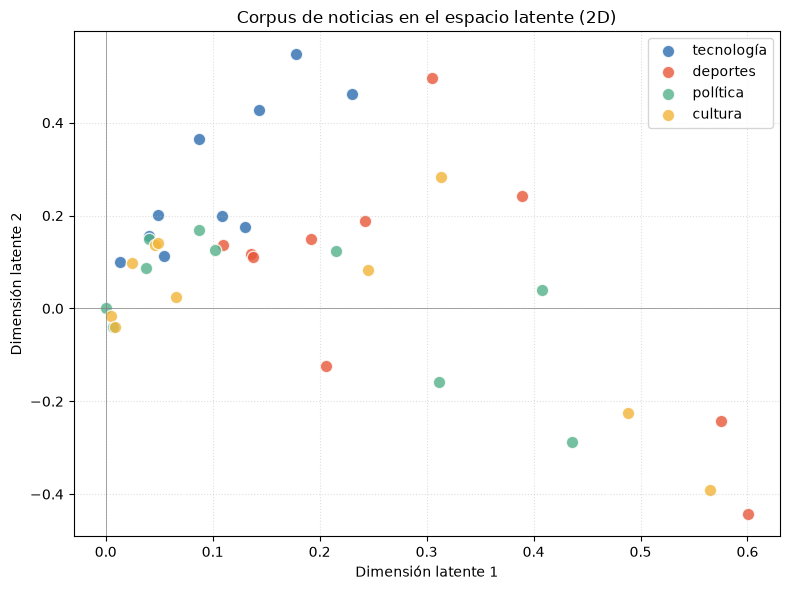

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#ojo, este gráfico solo toma 2 dimensiones latentes de 50, por lo que es imposible sacar buenas y adecuadas
#conclusiones de los datos a partir de esto. 

svd2 = TruncatedSVD(n_components=2, random_state=0)
X2 = svd2.fit_transform(X)

colores = {"tecnología": "#2C6DAF", "deportes": "#E75637",
           "política":   "#52B189", "cultura":  "#F2B538"}

fig, ax = plt.subplots(figsize=(8, 6))
for tema, c in colores.items():
    mask = np.array(LABELS) == tema
    ax.scatter(X2[mask, 0], X2[mask, 1], c=c, label=tema, s=80, alpha=0.8, edgecolor="white")

ax.axhline(0, color="gray", linewidth=0.5)
ax.axvline(0, color="gray", linewidth=0.5)
ax.set_xlabel("Dimensión latente 1")
ax.set_ylabel("Dimensión latente 2")
ax.set_title("Corpus de noticias en el espacio latente (2D)")
ax.legend(); ax.grid(True, linestyle=":", alpha=0.4)
plt.tight_layout(); plt.show()

Los documentos del mismo tema se agrupan, *sin que le hayamos dicho al modelo cuáles son los temas*. El significado emerge de la co-ocurrencia.

## 4. Embeddings de palabras (truco)

La matriz de componentes de SVD (`svd.components_`) tiene forma `K × V`: cada **columna** es la representación latente de un término. Es decir: cada palabra queda con un vector denso de K dimensiones. Eso es, en miniatura, un *embedding*.

una palabra tiene un vector de pesos a otras palabras y poder relacionarse entre sí. 

In [10]:
embeddings_terminos = svd.components_.T   # V términos x K dims
print(f"Embeddings de términos: {embeddings_terminos.shape}")

# Función para buscar palabras semánticamente cercanas
from sklearn.metrics.pairwise import cosine_similarity

def vecinos(palabra, k=5):
    if palabra not in terms:
        print(f"  '{palabra}' no está en el vocabulario.")
        return
    idx = list(terms).index(palabra)
    sims = cosine_similarity(embeddings_terminos[idx:idx+1], embeddings_terminos).ravel()
    top = np.argsort(-sims)[1:k+1]      # excluyendo la palabra misma
    print(f"Vecinos de '{palabra}':")
    for j in top:
        print(f"  {terms[j]:18s}  sim={sims[j]:.3f}")

Embeddings de términos: (52, 25)


In [11]:
vecinos("fútbol")

  'fútbol' no está en el vocabulario.


In [12]:
vecinos("gobierno")

  'gobierno' no está en el vocabulario.


In [13]:
vecinos("película")

  'película' no está en el vocabulario.


In [14]:
vecinos("tecnología")

Vecinos de 'tecnología':
  próximo             sim=0.741
  año                 sim=0.620
  tres                sim=0.610
  modelo              sim=0.384
  presentó            sim=0.277


## 5. Comparación: similitud en el espacio original vs. en el latente

In [15]:
# Tomemos dos pares de documentos:
#   Par A: dos noticias de tecnología que NO comparten muchas palabras
#   Par B: una de tecnología y una de deportes
i_A1, i_A2 = 0, 8     # tecnología, tecnología
i_B1, i_B2 = 0, 15    # tecnología, deportes

from sklearn.metrics.pairwise import cosine_similarity

S_orig = cosine_similarity(X)
S_red  = cosine_similarity(X_red)

print("Espacio TF-IDF original (alta dimensión, disperso):")
print(f"  sim(D{i_A1}, D{i_A2}) [{LABELS[i_A1]} vs {LABELS[i_A2]}] = {S_orig[i_A1,i_A2]:.3f}")
print(f"  sim(D{i_B1}, D{i_B2}) [{LABELS[i_B1]} vs {LABELS[i_B2]}] = {S_orig[i_B1,i_B2]:.3f}")
print()
print(f"Espacio latente ({K} dims, denso):")
print(f"  sim(D{i_A1}, D{i_A2}) [{LABELS[i_A1]} vs {LABELS[i_A2]}] = {S_red[i_A1,i_A2]:.3f}")
print(f"  sim(D{i_B1}, D{i_B2}) [{LABELS[i_B1]} vs {LABELS[i_B2]}] = {S_red[i_B1,i_B2]:.3f}")

Espacio TF-IDF original (alta dimensión, disperso):
  sim(D0, D8) [tecnología vs tecnología] = 0.000
  sim(D0, D15) [tecnología vs deportes] = 0.000

Espacio latente (25 dims, denso):
  sim(D0, D8) [tecnología vs tecnología] = -0.002
  sim(D0, D15) [tecnología vs deportes] = -0.027


Normalmente verás que en el espacio latente los pares del mismo tema aumentan su similitud, porque el modelo captura que comparten *significado*, aunque no compartan las mismas palabras exactas.

## 6. Ejercicios

In [ ]:
# Ejercicio 1: prueba la función vecinos() con varias palabras de tu interés
# ('tecnología', 'equipo', 'congreso', 'museo', ...). ¿Las palabras vecinas
# tienen sentido semántico?

# TODO:


In [ ]:
# Ejercicio 2: cambia el número de componentes K (prueba con 5, 20, 100) y
# observa qué pasa con la varianza explicada y con la calidad de los vecinos.

# TODO:


In [ ]:
# Ejercicio 3 (reflexión, sin código): ¿por qué con K muy pequeño se pierden
# matices y con K demasiado grande nos acercamos a la matriz TF-IDF original?

# TODO:


## Lo que sigue

Los embeddings que acabamos de construir son **estáticos**: cada palabra tiene un único vector, sin importar la frase en que aparezca. La palabra `"banco"` tiene el mismo vector en *"me senté en el banco del parque"* y en *"fui al banco a sacar dinero"*.

**Próxima clase:** atención y Transformers — representaciones que dependen del contexto.